<a href="https://colab.research.google.com/github/srilekab2024laiml-lang/Srileka-CodeBooster-2026/blob/main/Day2/Day2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully")
print(f"pandas version: {pd.__version__}")
print(f"sqlite3 version: {sqlite3.sqlite_version}")

All libraries imported successfully
pandas version: 2.2.2
sqlite3 version: 3.37.2


In [4]:
df = pd.read_csv('student_performance.csv')
print(f"Dataset loaded: {df.shape[0]} students, {df.shape}")

Dataset loaded: 30 students, (30, 13)


In [6]:
conn = sqlite3.connect(':memory:')
selected_columns_df = df[['student_id', 'name', 'department', 'math_score']]
selected_columns_df.to_sql('students', conn, index=False, if_exists='replace')
sql_query = "SELECT student_id, name, department, math_score FROM students"
sql_result_df = pd.read_sql_query(sql_query, conn)
display(sql_result_df.head())

,student_id,name,department,math_score
0,1001,Aarav Sharma,Computer Science,85
1,1002,Priya Patel,Computer Science,76
2,1003,Rohit Verma,Electronics,65
3,1004,Sneha Reddy,Mechanical,70
4,1005,Arjun Nair,Computer Science,92


In [8]:
conn = sqlite3.connect('internship.db')
selected_columns_df.to_sql('students', conn, index=False, if_exists='replace')
query_top_scorers = "SELECT name,department,math_score FROM students ORDER BY math_score DESC LIMIT 5"
top_scorers_df = pd.read_sql(query_top_scorers, conn)
print("Top 5 Math Scorers:")
print(top_scorers_df)
conn.close()

Top 5 Math Scorers:
             name        department  math_score
0      Ananya Das  Computer Science          95
1     Tanvi Mehta  Computer Science          93
2      Arjun Nair  Computer Science          92
3  Akanksha Yadav  Computer Science          91
4  Swati Kulkarni  Computer Science          90


In [10]:
conn = sqlite3.connect('internship.db')
df.to_sql('students', conn, index=False, if_exists='replace') # Write the full df to the database
query_high_attendance = "SELECT name, department, attendance_percentage FROM students WHERE attendance_percentage > 93 AND department NOT IN ('Mechanical') ORDER BY attendance_percentage DESC"
high_attendance_df = pd.read_sql(query_high_attendance, conn)
print("Students with high attendance (above 90%) excluding Mechanical departments:")
print(high_attendance_df)
conn.close()

Students with high attendance (above 90%) excluding Mechanical departments:
             name        department  attendance_percentage
0      Ananya Das  Computer Science                     98
1     Tanvi Mehta  Computer Science                     97
2     Divya Singh  Computer Science                     96
3  Akanksha Yadav  Computer Science                     95
4  Swati Kulkarni  Computer Science                     94


In [11]:
conn = sqlite3.connect('internship.db')
query_a_to_f_names = """SELECT name FROM students WHERE
    name LIKE 'A%' OR
    name LIKE 'B%' OR
    name LIKE 'C%' OR
    name LIKE 'D%' OR
    name LIKE 'E%' OR
    name LIKE 'F%'
ORDER BY name;"""
a_to_f_names_df = pd.read_sql(query_a_to_f_names, conn)
print("Students whose names start with A to F:")
print(a_to_f_names_df)
conn.close()

Students whose names start with A to F:
             name
0    Aarav Sharma
1     Ajay Tiwari
2  Akanksha Yadav
3       Amit Bose
4      Ananya Das
5      Arjun Nair
6  Deepak Chauhan
7     Divya Singh


In [20]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('internship.db')
sql_query = """
SELECT
    department,
    COUNT(*) AS num_students,
    ROUND(AVG(math_score), 2) AS avg_math,
    ROUND(AVG(science_score), 2) AS avg_science,
    ROUND(AVG(programming_score), 2) AS avg_programming,
    ROUND(AVG(attendance_percentage), 2) AS avg_attendance
FROM students
GROUP BY department
ORDER BY num_students DESC;
"""

department_summary_df = pd.read_sql(sql_query, conn)
print("Department-wise Summary:")
print(department_summary_df)
conn.close()

Department-wise Summary:
         department  num_students  avg_math  avg_science  avg_programming  \
0  Computer Science            13     85.62        84.46            89.23   
1        Mechanical             6     71.00        76.50            49.33   
2       Electronics             6     71.00        74.17            61.50   
3             Civil             5     63.40        66.60            40.60   

   avg_attendance  
0           90.69  
1           83.50  
2           80.33  
3           74.60  


In [27]:
conn = sqlite3.connect('internship.db')
cursor = conn.cursor()
chart_sql = """
SELECT department , ROUND(AVG(math_score)) AS  avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""
data = pd.read_sql(chart_sql,conn)
conn.close()
print("=== DataBase Connected Successfully ===")
print("")
print(data)
conn.close()

=== DataBase Connected Successfully ===

         department  avg_math
0  Computer Science      86.0
1        Mechanical      71.0
2       Electronics      71.0
3             Civil      63.0


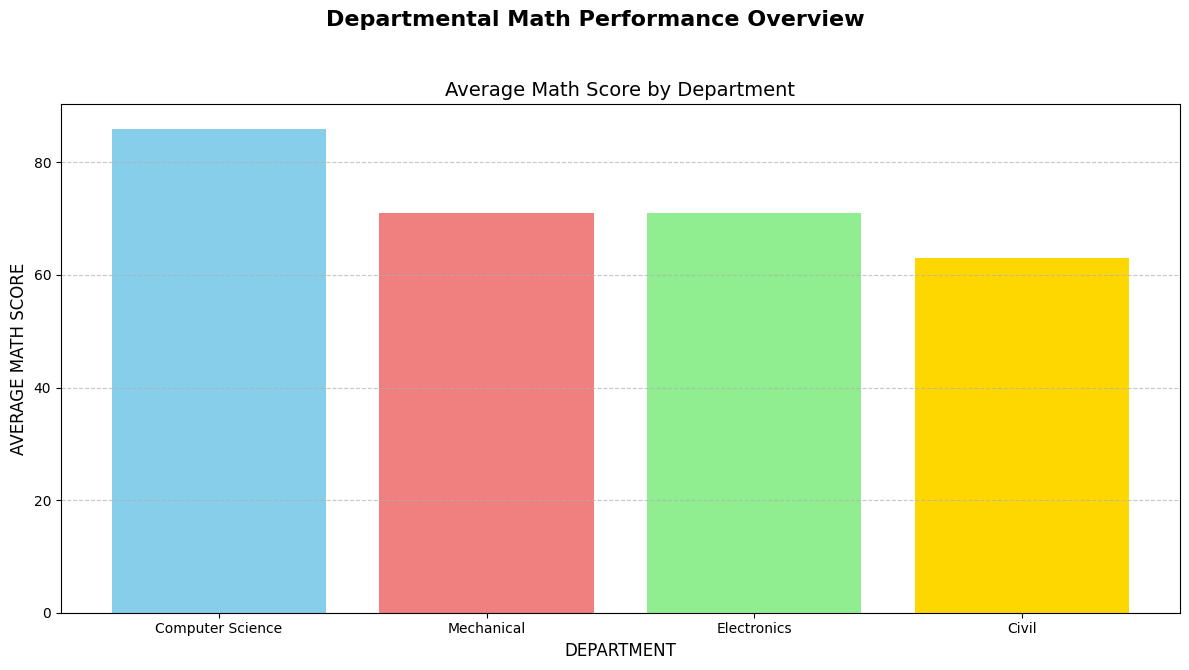

In [28]:
fig, ax = plt.subplots(figsize=(12, 7))
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold']

plt.suptitle("Departmental Math Performance Overview", fontsize=16, fontweight='bold')
plt.xlabel("DEPARTMENT", fontsize=12)
plt.ylabel("AVERAGE MATH SCORE", fontsize=12)
plt.title("Average Math Score by Department", fontsize=14)
ax.bar(data['department'], data['avg_math'], color=colors)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [32]:
import matplotlib.pyplot as plt
import sqlite3
import pandas as pd

conn = sqlite3.connect('internship.db')
cursor = conn.cursor()
chart_sql = """
SELECT department , AVG(attendance_percentage) AS avg_attendance
FROM students
GROUP BY department
ORDER BY attendance_percentage DESC
"""
data = pd.read_sql(chart_sql,conn)
print("=== DataBase Connected Successfully ===")
print("")
print(data)
conn.close()

=== DataBase Connected Successfully ===

         department  avg_attendance
0        Mechanical       83.500000
1  Computer Science       90.692308
2             Civil       74.600000
3       Electronics       80.333333


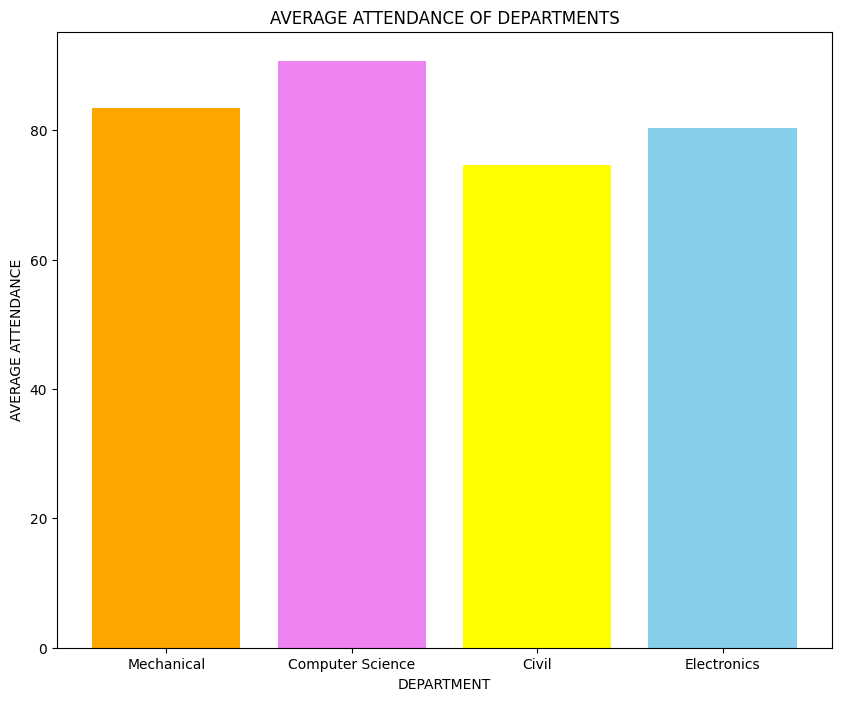

In [42]:
fig , ax = plt.subplots(figsize=(10,8))
plt.title("AVERAGE ATTENDANCE OF DEPARTMENTS")
plt.xlabel("DEPARTMENT")
plt.ylabel("AVERAGE ATTENDANCE")
plt.bar(data['department'],data['avg_attendance'], color = ['orange','violet','yellow','skyblue'])
plt.show()

=== Data Processed Successfully ===

         department  avg_attendance
1  Computer Science       90.692308
3        Mechanical       83.500000
2       Electronics       80.333333
0             Civil       74.600000


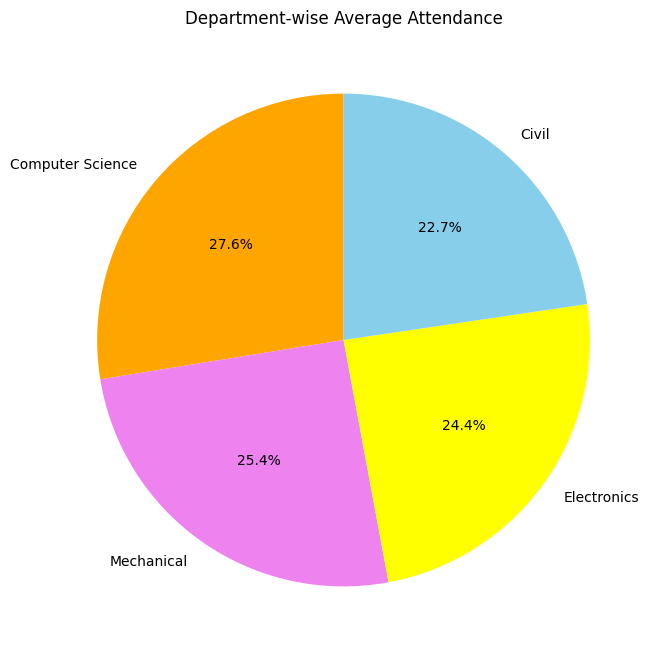

In [43]:
import matplotlib.pyplot as plt
import pandas as pd
data = df.groupby('department')['attendance_percentage'].mean().reset_index()
data = data.rename(columns={'attendance_percentage': 'avg_attendance'})
data = data.sort_values(by='avg_attendance', ascending=False)
print("=== Data Processed Successfully ===\n")
print(data)
plt.figure(figsize=(8, 8))

colors = ['orange', 'violet', 'yellow', 'skyblue', 'lightgreen']

plt.pie(
    data['avg_attendance'],
    labels=data['department'],
    colors=colors[:len(data)],
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Department-wise Average Attendance")
plt.show()

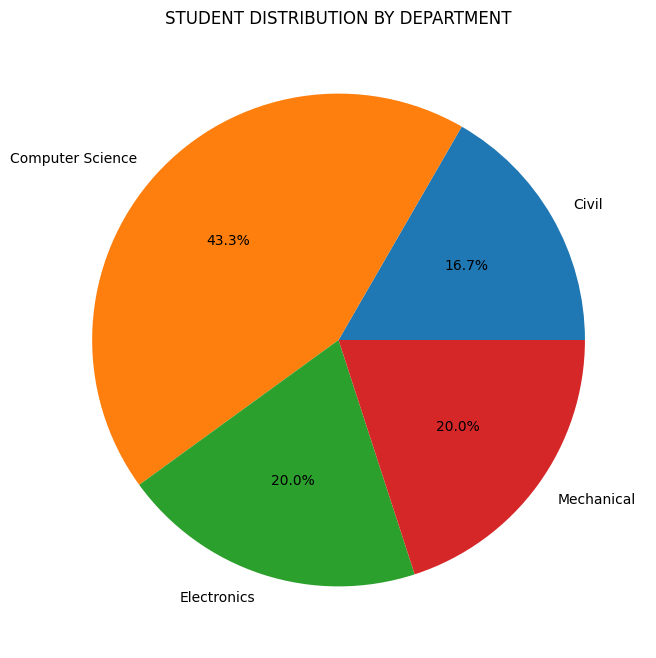

In [54]:
import sqlite3 as sql
import pandas as pd
import matplotlib.pyplot as plt

# Connect database
conn = sql.connect('internship.db') # Changed to internship.db

# SQL query
chart_sql = """
SELECT department, COUNT(student_id) AS student_count
FROM students
GROUP BY department
"""
department_data = pd.read_sql_query(chart_sql, conn)

conn.close()

fig, ax = plt.subplots(figsize=(8,8))

ax.pie(
    department_data['student_count'],
    labels=department_data['department'],
    autopct='%1.1f%%'
)

ax.set_title("STUDENT DISTRIBUTION BY DEPARTMENT")

plt.show()

In [56]:
import matplotlib.pyplot as plt
import sqlite3 as sql
import pandas as pd

conn = sql.connect('internship.db')
cursor = conn.cursor()
chart_sql = """
SELECT gender , ROUND(AVG(programming_score)) AS avg_programming_score
FROM students
WHERE gender = "Female"
GROUP BY gender
ORDER BY avg_programming_score DESC
"""
data = pd.read_sql(chart_sql,conn)
print("=== DataBase Connected Successfully ===")
print("")
print(data)
conn.close()

=== DataBase Connected Successfully ===

   gender  avg_programming_score
0  Female                   70.0


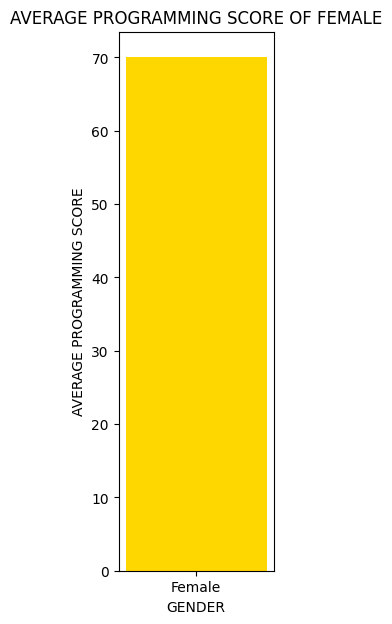

In [57]:
fig , ax = plt.subplots(figsize=(2,7))
plt.title("AVERAGE PROGRAMMING SCORE OF FEMALE")
plt.xlabel("GENDER")
plt.ylabel("AVERAGE PROGRAMMING SCORE")
plt.bar(data['gender'],data['avg_programming_score'], color = ['gold'])
plt.show()

=== Database Connected Successfully ===

   gender  avg_programming_score
0  Female                   70.2


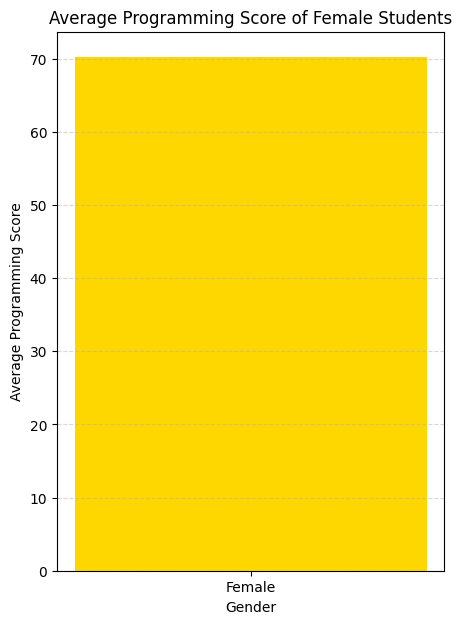

In [59]:
import matplotlib.pyplot as plt
import sqlite3 as sql
import pandas as pd

# Connect to database
conn = sql.connect('internship.db')
cursor = conn.cursor()

# SQL Query
chart_sql = """
SELECT
    gender,
    ROUND(AVG(programming_score), 2) AS avg_programming_score
FROM students
WHERE gender = 'Female'
GROUP BY gender
ORDER BY avg_programming_score DESC;
"""

# Read data from database
data = pd.read_sql_query(chart_sql, conn)

print("=== Database Connected Successfully ===")
print("")
print(data)

# Close connection
conn.close()

# Create Bar Chart
fig, ax = plt.subplots(figsize=(5, 7))

plt.title("Average Programming Score of Female Students")
plt.xlabel("Gender")
plt.ylabel("Average Programming Score")

# Bar chart
plt.bar(
    data['gender'],
    data['avg_programming_score'],
    color=['gold']
)

# Grid lines
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Show chart
plt.show()

=== WHERE CLAUSE EXAMPLE ===

   gender  avg_programming_score
0  Female                   70.2


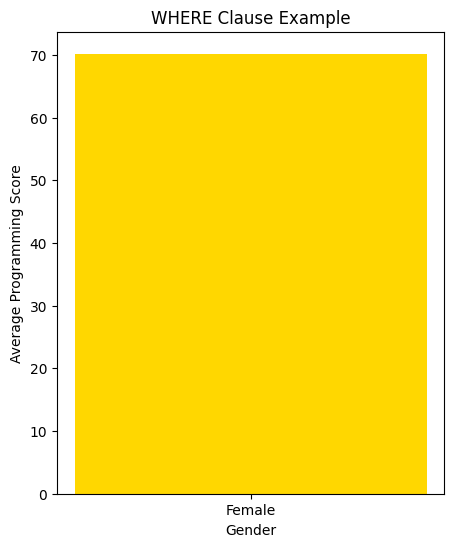

In [60]:
import matplotlib.pyplot as plt
import sqlite3 as sql
import pandas as pd

# Connect to database
conn = sql.connect('internship.db')
cursor = conn.cursor()

# SQL Query using WHERE
chart_sql = """
SELECT
    gender,
    ROUND(AVG(programming_score), 2) AS avg_programming_score
FROM students
WHERE gender = 'Female'
GROUP BY gender;
"""

# Read data
data = pd.read_sql_query(chart_sql, conn)

print("=== WHERE CLAUSE EXAMPLE ===")
print("")
print(data)

# Close connection
conn.close()

# Create Bar Chart
fig, ax = plt.subplots(figsize=(5, 6))

plt.title("WHERE Clause Example")
plt.xlabel("Gender")
plt.ylabel("Average Programming Score")

plt.bar(
    data['gender'],
    data['avg_programming_score'],
    color=['gold']
)

plt.show()